# Setup and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Identifying Missing Values

Missing values per column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


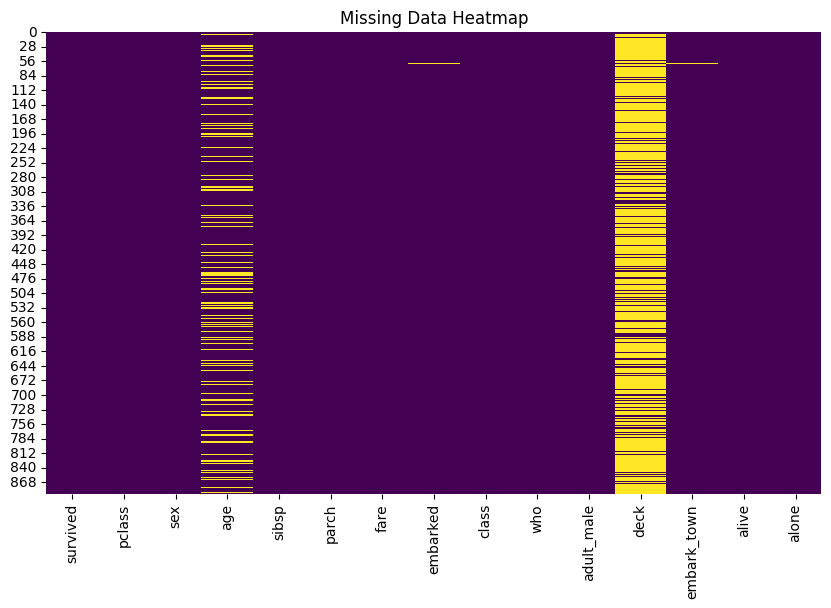

In [2]:
print("Missing values per column:\n", df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Complete Case Analysis

In [3]:
df_complete = df.dropna()
print("Original shape:", df.shape)
print("Shape after complete case analysis:", df_complete.shape)

Original shape: (891, 15)
Shape after complete case analysis: (182, 15)


# Handling Missing Categorical Data

In [4]:
df["embark_town"].fillna(df["embark_town"].mode()[0], inplace=True)
df["deck"].fillna("Unknown", inplace=True)
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)
print("Missing categorical values after imputation:")
print(df[["embark_town", "deck", "embarked"]].isnull().sum())

Missing categorical values after imputation:
embark_town    0
deck           0
embarked       0
dtype: int64


/tmp/ipykernel_21734/2835978851.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embark_town"].fillna(df["embark_town"].mode()[0], inplace=True)
/tmp/ipykernel_21734/2835978851.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

# Handling Missing Numerical Data

/tmp/ipykernel_21734/614826894.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean["age"].fillna(df_mean["age"].mean(), inplace=True)
/tmp/ipykernel_21734/614826894.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

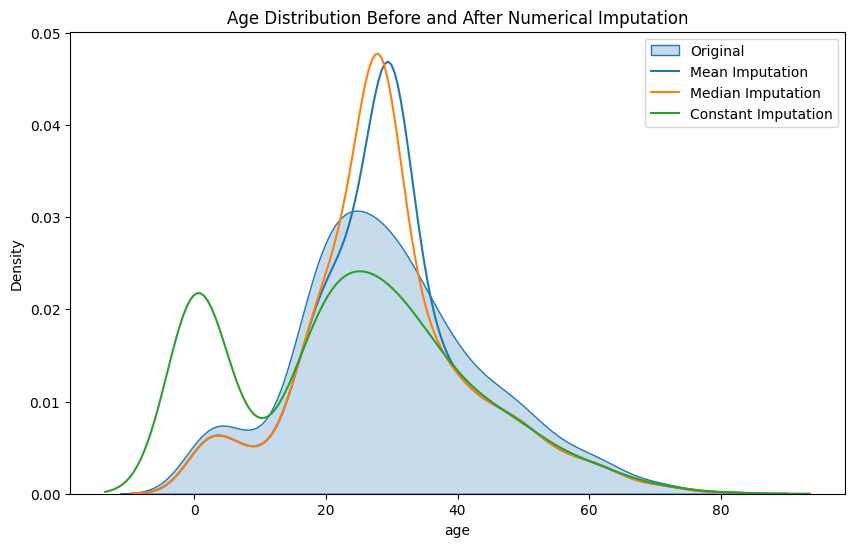

In [5]:
df_mean = df.copy()
df_median = df.copy()
df_constant = df.copy()

df_mean["age"].fillna(df_mean["age"].mean(), inplace=True)
df_median["age"].fillna(df_median["age"].median(), inplace=True)
df_constant["age"].fillna(0, inplace=True)

plt.figure(figsize=(10, 6))
sns.kdeplot(df["age"], label="Original", fill=True)
sns.kdeplot(df_mean["age"], label="Mean Imputation", fill=False)
sns.kdeplot(df_median["age"], label="Median Imputation", fill=False)
sns.kdeplot(df_constant["age"], label="Constant Imputation", fill=False)
plt.title("Age Distribution Before and After Numerical Imputation")
plt.legend()
plt.show()

# KNN Imputer

In [6]:
imputer_knn = KNNImputer(n_neighbors=3)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df_knn = df.copy()
df_knn[numerical_cols] = imputer_knn.fit_transform(df[numerical_cols])

print("Missing numerical values after KNN Imputation:")
print(df_knn[numerical_cols].isnull().sum())
df_knn[numerical_cols].head()

Missing numerical values after KNN Imputation:
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500


# Iterative Imputer

In [7]:
imputer_iter = IterativeImputer(max_iter=10, random_state=0)
df_iter = df.copy()
df_iter[numerical_cols] = imputer_iter.fit_transform(df[numerical_cols])

print("Missing numerical values after Iterative Imputation:")
print(df_iter[numerical_cols].isnull().sum())
df_iter[numerical_cols].head()

Missing numerical values after Iterative Imputation:
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500


# Technique Comparison via Machine Learning

In [8]:
def train_eval_model(data, name):
    X = data[["age", "fare", "pclass"]]
    y = data["survived"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"Accuracy with {name}: {accuracy_score(y_test, preds):.4f}")

train_eval_model(df_complete, "Complete Case Analysis")
train_eval_model(df_knn, "KNN Imputation")
train_eval_model(df_iter, "Iterative Imputation")

Accuracy with Complete Case Analysis: 0.7297
Accuracy with KNN Imputation: 0.7598
Accuracy with Iterative Imputation: 0.7598


# Reload Original Data for Comparison

In [9]:
df_orig = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
methods = {"Original": df_orig, "Mean": df_mean, "Median": df_median, "Constant (0)": df_constant, "KNN (k=3)": df_knn, "Iterative": df_iter}

# Statistics of Age Before and After Imputation

In [10]:
stats = []
for name, mdf in methods.items():
    s = mdf['age'].describe()[['count', 'mean', 'std', 'min', '50%', 'max']]
    s['skew'] = mdf['age'].skew()
    s.name = name
    stats.append(s)
print(pd.DataFrame(stats))
print("-" * 50)

missing_mask = df_orig['age'].isnull()
knn_imputed = df_knn.loc[missing_mask, 'age']
iter_imputed = df_iter.loc[missing_mask, 'age']

print(f"KNN distinct imputed values: {knn_imputed.nunique()}")
print(f"KNN min: {knn_imputed.min():.2f}, max: {knn_imputed.max():.2f}")
print(f"Iterative distinct imputed values: {iter_imputed.nunique()}")
print(f"Iterative min: {iter_imputed.min():.2f}, max: {iter_imputed.max():.2f}")

              count       mean        std       min        50%   max      skew
Original      714.0  29.699118  14.526497  0.420000  28.000000  80.0  0.389108
Mean          891.0  29.699118  13.002015  0.420000  29.699118  80.0  0.434488
Median        891.0  29.361582  13.019697  0.420000  28.000000  80.0  0.510245
Constant (0)  891.0  23.799293  17.596074  0.000000  24.000000  80.0  0.262862
KNN (k=3)     891.0  29.762226  13.555810  0.420000  28.000000  80.0  0.407657
Iterative     891.0  29.314779  13.699431 -5.074562  29.000000  80.0  0.333241
--------------------------------------------------
KNN distinct imputed values: 59
KNN min: 4.33, max: 62.33
Iterative distinct imputed values: 94
Iterative min: -5.07, max: 44.86


# Distribution Comparison for All Methods

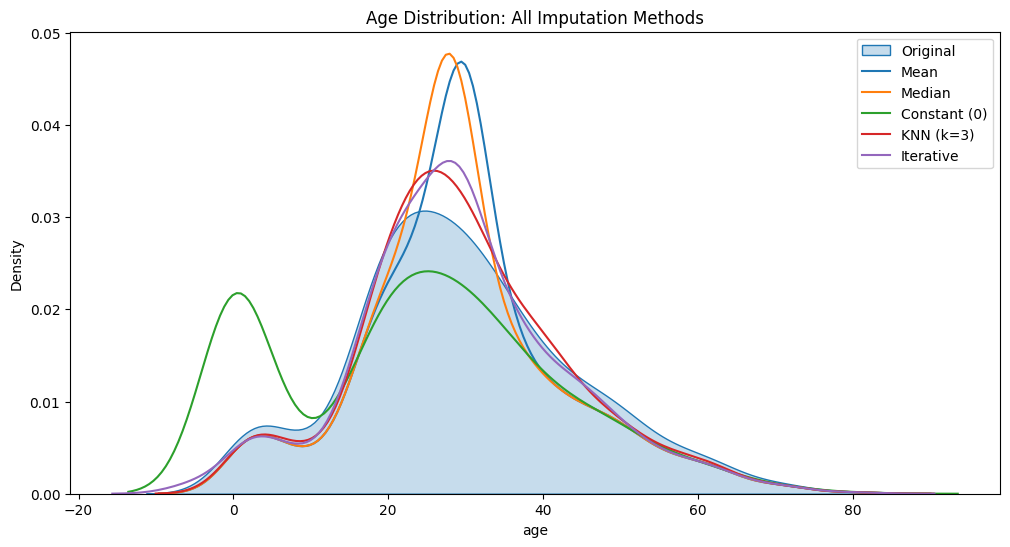

In [11]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_orig['age'], label='Original', fill=True)
sns.kdeplot(df_mean['age'], label='Mean', fill=False)
sns.kdeplot(df_median['age'], label='Median', fill=False)
sns.kdeplot(df_constant['age'], label='Constant (0)', fill=False)
sns.kdeplot(df_knn['age'], label='KNN (k=3)', fill=False)
sns.kdeplot(df_iter['age'], label='Iterative', fill=False)
plt.title('Age Distribution: All Imputation Methods')
plt.legend()
plt.show()

# KNN vs Mean and Median Imputation

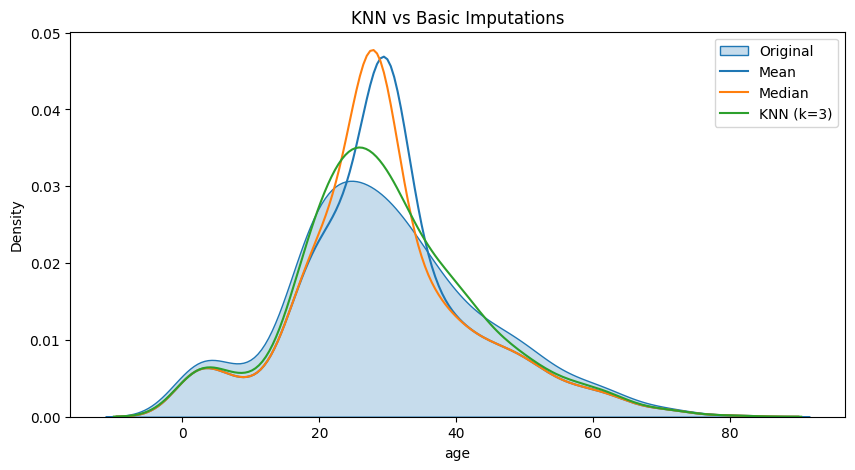

In [12]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_orig['age'], label='Original', fill=True)
sns.kdeplot(df_mean['age'], label='Mean', fill=False)
sns.kdeplot(df_median['age'], label='Median', fill=False)
sns.kdeplot(df_knn['age'], label='KNN (k=3)', fill=False)
plt.title('KNN vs Basic Imputations')
plt.legend()
plt.show()

KNN imputation preserves the natural distribution of the age feature much better than simple mean or median imputation. While mean and median create an artificial spike at a single value, KNN estimates plausible varied values based on similarities with other features, keeping the variance closer to the original.

# Effect of Imputation on Feature Relationships

Correlation of age with other features:
              pclass   fare  sibsp  parch  survived
Original      -0.369  0.096 -0.308 -0.189    -0.077
Mean          -0.331  0.092 -0.233 -0.179    -0.070
Median        -0.340  0.097 -0.233 -0.172    -0.065
Constant (0)  -0.361  0.136 -0.185 -0.049     0.011
KNN (k=3)     -0.385  0.109 -0.195 -0.172    -0.095
Iterative     -0.405  0.092 -0.380 -0.220    -0.080


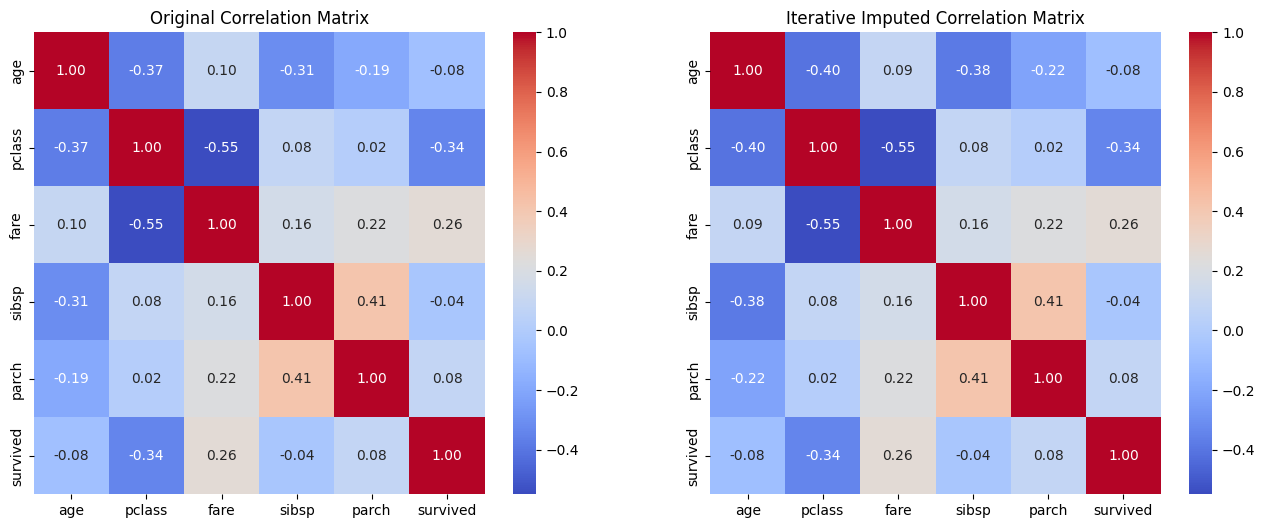

In [13]:
corrs = []
features = ['pclass', 'fare', 'sibsp', 'parch', 'survived']
for name, mdf in methods.items():
    c = [mdf['age'].corr(mdf[f]) for f in features]
    corrs.append(c)
corr_df = pd.DataFrame(corrs, index=methods.keys(), columns=features).round(3)
print("Correlation of age with other features:")
print(corr_df)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(df_orig[['age'] + features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Original Correlation Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(df_iter[['age'] + features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Iterative Imputed Correlation Matrix')
plt.show()

# Convergence of the Iterative Imputer

In [14]:
print(f"imputer_iter.n_iter_: {imputer_iter.n_iter_} (converged before max_iter=10)")
print("-" * 50)

missing_mask = df_orig['age'].isnull()
for max_i in [1, 2, 3, 5, 10]:
    imp = IterativeImputer(max_iter=max_i, random_state=0)
    res = imp.fit_transform(df_orig[numerical_cols])
    age_idx = list(numerical_cols).index('age')
    imputed_ages = res[missing_mask, age_idx]
    print(f"max_iter={max_i}: imputed mean={imputed_ages.mean():.4f}, std={imputed_ages.std():.4f}")

imputer_iter.n_iter_: 2 (converged before max_iter=10)
--------------------------------------------------
max_iter=1: imputed mean=27.7644, std=9.5203
max_iter=2: imputed mean=27.7644, std=9.5203
max_iter=3: imputed mean=27.7644, std=9.5203
max_iter=5: imputed mean=27.7644, std=9.5203
max_iter=10: imputed mean=27.7644, std=9.5203


/home/sanaullah/University-Stuff/University-Projects/venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


# Checking for Impossible Values

In [15]:
neg_count = (df_iter['age'] < 0).sum()
min_age = df_iter['age'].min()
print(f"Iterative neg count: {neg_count}, min age: {min_age:.2f}")

imp_fixed = IterativeImputer(max_iter=10, random_state=0, min_value=0)
df_iter_fixed = df_iter.copy()
df_iter_fixed[numerical_cols] = imp_fixed.fit_transform(df_orig[numerical_cols])
print(f"Fixed Iterative neg count: {(df_iter_fixed['age'] < 0).sum()}, min age: {df_iter_fixed['age'].min():.2f}")

Iterative neg count: 7, min age: -5.07
Fixed Iterative neg count: 0, min age: 0.00


# Accuracy of All Techniques

In [16]:
accs = []
for name, mdf in [("Complete Case Analysis", df_complete), ("Mean Imputation", df_mean), 
                  ("Median Imputation", df_median), ("Constant Imputation", df_constant), 
                  ("KNN Imputation", df_knn), ("Iterative Imputation", df_iter)]:
    
    train_eval_model(mdf, name)
    
    X = mdf[['age', 'fare', 'pclass']]
    y = mdf['survived']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accs.append({"Method": name, "Accuracy": accuracy_score(y_test, preds), "Train Rows": len(X_train), "Test Rows": len(X_test)})

print("-" * 50)
print(pd.DataFrame(accs))

Accuracy with Complete Case Analysis: 0.7297


Accuracy with Mean Imputation: 0.7374
Accuracy with Median Imputation: 0.7374


Accuracy with Constant Imputation: 0.7151


Accuracy with KNN Imputation: 0.7598
Accuracy with Iterative Imputation: 0.7598
--------------------------------------------------
                   Method  Accuracy  Train Rows  Test Rows
0  Complete Case Analysis  0.729730         145         37
1         Mean Imputation  0.737430         712        179
2       Median Imputation  0.737430         712        179
3     Constant Imputation  0.715084         712        179
4          KNN Imputation  0.759777         712        179
5    Iterative Imputation  0.759777         712        179


Note that Complete Case Analysis results in a significantly smaller training and test set because it drops all rows with any missing values. Therefore, its accuracy is not directly comparable to the imputation methods which retain all 891 rows of the dataset.

# Leakage-Safe Comparison (Optional)

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X = df_orig[['age', 'fare', 'pclass']]
y = df_orig['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipelines = {
    "Simple (Median)": Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', LogisticRegression())]),
    "KNN": Pipeline([('imputer', KNNImputer(n_neighbors=3)), ('model', LogisticRegression())]),
    "Iterative": Pipeline([('imputer', IterativeImputer(min_value=0, random_state=0)), ('model', LogisticRegression())])
}

for name, p in pipelines.items():
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    print(f"Pipeline {name} Test Accuracy: {accuracy_score(y_test, preds):.4f}")

Pipeline Simple (Median) Test Accuracy: 0.7374
Pipeline KNN Test Accuracy: 0.7430
Pipeline Iterative Test Accuracy: 0.7486


By using scikit-learn Pipelines, we ensure that the imputation parameters (like mean, median, or KNN distances) are computed strictly on the training set. This avoids data leakage, where information from the test set could inadvertently influence the model during training.

# Summary
* Advanced imputers (KNN and Iterative) preserved the variance of the `age` column significantly better than simple methods. For instance, KNN maintained a standard deviation of 13.56, which is very close to the original 14.53, whereas mean and median dropped it to roughly 13.0.
* Simple imputations severely skewed the correlation of `age` with other features. The Iterative imputer strengthened the correlation between `age` and `pclass` from -0.369 (Original) to -0.405, while constant imputation reduced it to -0.361.
* The Iterative imputer predicted 7 impossible negative age values (minimum -5.07) due to its regression nature, but this was completely resolved by specifying `min_value=0`.
* Iterative imputation converged very quickly on this dataset, stabilising after just 2 iterations out of the maximum 10.
* Machine learning performance improved when using advanced imputations within a leakage-safe pipeline, with Iterative (0.7486) and KNN (0.7430) outperforming Simple Median imputation (0.7374).